In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

In [3]:
mpl.rcParams["axes.formatter.use_mathtext"] = True
mpl.rcParams["mathtext.fontset"] = "cm"
mpl.rcParams["font.family"] = "Nimbus Roman"
mpl.rcParams["axes.spines.right"] = False
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.labelsize"] = 14
mpl.rcParams["xtick.labelsize"] = 14
mpl.rcParams["ytick.labelsize"] = 14
mpl.rcParams["legend.fontsize"] = 14
mpl.rcParams["figure.titlesize"] = 16
mpl.rcParams["figure.labelsize"] = 18
mpl.rcParams["font.style"] = "normal"
mpl.rcParams["legend.fontsize"] = 12
mpl.rcParams["legend.title_fontsize"] = 12
# mpl.rcParams["text.usetex"] = False

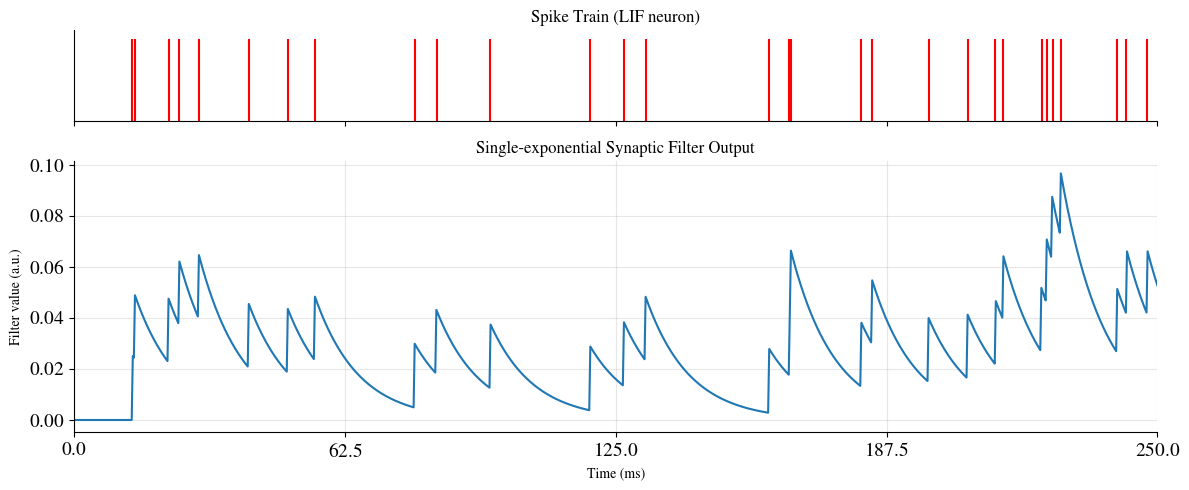

In [18]:
# --- simulation parameters ---
T = 250 # total time (ms)
t = np.linspace(0, T, 1000)
dt = t[1] - t[0]
n_steps = len(t)

np.random.seed(410)

spike_times = np.random.uniform(T * .05, T, size=30)

spike_train = np.zeros(n_steps, dtype=float)
for st in spike_times:
    idx = int(np.round(st / dt))
    if 0 <= idx < n_steps:
        spike_train[idx] = 1.0

# --- single exponential synaptic filter (causal kernel) ---
tau_s = 10.0  # ms
# kernel length: sufficiently long to capture decay

syn_out = np.zeros_like(t)
for i in range(1, n_steps):
    syn_out[i] = syn_out[i-1] * np.exp(-dt / tau_s) + spike_train[i] * (1.0 / tau_s) * dt

# --- plotting (two panels horizontally) ---
fig, axs = plt.subplots(2, 1, figsize=(12, 5), sharey=False, sharex=True, gridspec_kw={'height_ratios': [1, 3]})

# Left panel: spike raster (single neuron)
axs[0].set_title("Spike Train (LIF neuron)", fontsize=12)
for st in spike_times:
    axs[0].vlines(st, 0, 1, color='red', linewidth=1.5)
axs[0].set_xlim(0, T)
axs[0].set_ylim(0, 1.1)
axs[0].set_yticks([])
# axs[0].set_xlabel("Time (ms)", fontsize=10)
axs[0].set_xticks(np.linspace(0, T, 5))

# Right panel: synaptic filter output
axs[1].set_title("Single-exponential Synaptic Filter Output", fontsize=12)
axs[1].plot(t, syn_out, color='tab:blue', lw=1.5)
axs[1].set_xlim(0, T)
axs[1].set_xlabel("Time (ms)", fontsize=10)
axs[1].set_ylabel("Filter value (a.u.)", fontsize=10)
axs[1].grid(alpha=0.3)

plt.tight_layout()
# Save to file if desired
plt.savefig("lif_spikes_and_synfilter.pdf", dpi=300, bbox_inches='tight')
plt.show()
